# Example of Stata Analysis

## Overview

This notebook provides a step-by-step introduction to **panel data analysis** using Stata. It mirrors the Python analysis (notebook-01) using the same synthetic Barro-style growth dataset, demonstrating that the same econometric results can be reproduced across different software environments.

The workflow follows three stages:

1.  **Data import** — load the panel dataset and declare its structure
2.  **Exploratory data analysis** — descriptive statistics, visualization, and correlation analysis
3.  **Fixed effects regression** — estimate growth equations using `reghdfe`

**Prerequisites:** Stata must be installed and the `nbstata` kernel registered. The packages `reghdfe` and `estout` must be installed (`ssc install reghdfe` and `ssc install estout`).

## 1. Data Import

In Stata, panel data must be explicitly declared using `xtset`. This tells Stata which variable identifies the entities (countries) and which variable identifies time periods. The `delta(5)` option indicates that observations are spaced 5 years apart.

In [1]:
* Clear memory and set the random seed for reproducibility
clear all
set seed 42

* Load the panel dataset generated by the Python notebook
import delimited "../data/panel_growth.csv", clear

* Declare the panel structure: country is the entity, year is the time variable
* delta(5) tells Stata the time gap between observations is 5 years
xtset country year, delta(5)

* Inspect the dataset: variable names, types, and number of observations
describe

(encoding automatically selected: ISO-8859-1)
(8 vars, 240 obs)

Panel variable: country (strongly balanced)
 Time variable: year, 1990 to 2015
         Delta: 5 units

Contains data
 Observations:           240                  
    Variables:             8                  
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
country         byte    %8.0g                 
year            int     %8.0g                 
gdp_growth      float   %9.0g                 
ln_initial_gdp  float   %9.0g                 
investment      float   %9.0g                 
schooling       float   %9.0g                 
pop_growth      float   %9.0g                 
trade_openness  float   %9.0g                 
-------------------------------------------------------------------------------
Sorte

## 2. Exploratory Data Analysis

### Descriptive Statistics

We compare summary statistics at the beginning (1990) and end (2015) of the sample period. Each variable appears twice in the table, allowing the reader to see how the distribution has changed over 25 years.

In [2]:
* Define the variables and their labels for the table
local varlist "gdp_growth ln_initial_gdp investment schooling pop_growth trade_openness"
local labels `" "GDP growth" "Log initial GDP" "Investment" "Schooling" "Pop. growth" "Trade openness" "'

* --- Open output files for all three export formats ---
* Markdown (for the manuscript)
tempname fh
file open `fh' using "../tables/tbl-stata-descriptive.md", write replace
file write `fh' "| Variable | Mean | Median | SD | IQR | Min | Max |" _n
file write `fh' "|:---|:---:|:---:|:---:|:---:|:---:|:---:|" _n

* LaTeX (for standalone use)
tempname fh2
file open `fh2' using "../tables/tbl-stata-descriptive.tex", write replace
file write `fh2' "\begin{tabular}{lcccccc}" _n
file write `fh2' "\toprule" _n
file write `fh2' "Variable & Mean & Median & SD & IQR & Min & Max \\" _n
file write `fh2' "\midrule" _n

* CSV (for data reuse)
tempname fh3
file open `fh3' using "../tables/tbl-stata-descriptive.csv", write replace
file write `fh3' "Variable,Mean,Median,SD,IQR,Min,Max" _n

* --- Compute statistics for each variable at each time point ---
local v = 1
foreach var of local varlist {
    local vlabel : word `v' of `labels'

    foreach yr in 1990 2015 {
        * Subset the data to one period and compute detailed summary statistics
        preserve
        quietly keep if year == `yr'
        quietly summarize `var', detail
        local mn  : display %7.2f r(mean)
        local md  : display %7.2f r(p50)     // Median (50th percentile)
        local sd  : display %7.2f r(sd)
        local iqr : display %7.2f (r(p75) - r(p25))  // Interquartile range
        local lo  : display %7.2f r(min)
        local hi  : display %7.2f r(max)
        restore

        * Write one row to each output file
        file write `fh'  "| `vlabel' (`yr') | `=trim("`mn'")' | `=trim("`md'")' | `=trim("`sd'")' | `=trim("`iqr'")' | `=trim("`lo'")' | `=trim("`hi'")' |" _n
        file write `fh2' "`vlabel' (`yr') & `=trim("`mn'")' & `=trim("`md'")' & `=trim("`sd'")' & `=trim("`iqr'")' & `=trim("`lo'")' & `=trim("`hi'")' \\" _n
        file write `fh3' "`vlabel' (`yr'),`=trim("`mn'")',`=trim("`md'")',`=trim("`sd'")',`=trim("`iqr'")',`=trim("`lo'")',`=trim("`hi'")'" _n
    }
    local v = `v' + 1
}

* Close all output files
file close `fh'
file write `fh2' "\bottomrule" _n
file write `fh2' "\end{tabular}" _n
file close `fh2'
file close `fh3'

* Display the Markdown table inline
type "../tables/tbl-stata-descriptive.md"

| Variable | Mean | Median | SD | IQR | Min | Max |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| GDP growth (1990) | -0.06 | 0.79 | 2.64 | 4.44 | -4.61 | 4.09 |
| GDP growth (2015) | 1.06 | 1.28 | 2.72 | 3.40 | -5.45 | 6.29 |
| Log initial GDP (1990) | 7.08 | 7.00 | 1.24 | 1.50 | 4.44 | 10.02 |
| Log initial GDP (2015) | 6.97 | 6.87 | 1.06 | 1.58 | 5.24 | 9.51 |
| Investment (1990) | 14.11 | 14.53 | 4.28 | 4.65 | 3.54 | 22.36 |
| Investment (2015) | 15.58 | 15.32 | 5.13 | 5.94 | 3.33 | 26.64 |
| Schooling (1990) | 5.91 | 5.50 | 3.36 | 4.99 | -1.23 | 13.15 |
| Schooling (2015) | 5.99 | 6.50 | 3.17 | 3.86 | -1.69 | 12.15 |
| Pop. growth (1990) | 1.55 | 1.53 | 0.57 | 0.54 | -0.01 | 2.97 |
| Pop. growth (2015) | 1.57 | 1.51 | 0.81 | 1.28 | 0.07 | 3.29 |
| Trade openness (1990) | 49.74 | 48.56 | 17.75 | 22.45 | 7.84 | 85.43 |
| Trade openness (2015) | 54.82 | 51.49 | 19.70 | 26.22 | 22.44 | 106.18 |

### GDP Growth Over Time

Box plots show the distribution of GDP growth across 40 countries within each period. The box spans the interquartile range, the line inside marks the median, and the dashed line at zero separates positive from negative growth.

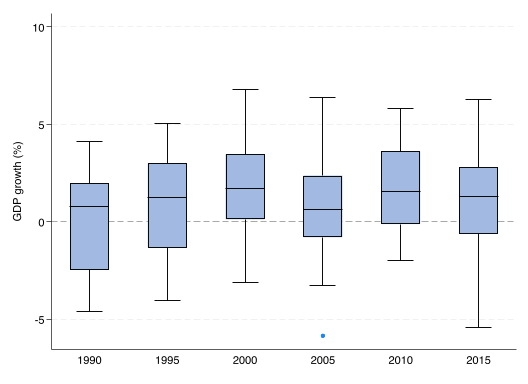

In [3]:
#| label: fig-stata-growth-time
#| fig-cap: "Distribution of GDP per capita growth rates by period (Stata)."

graph box gdp_growth, over(year) ///
    box(1, fcolor("68 114 196") lcolor(black)) ///
    yline(0, lcolor(gray) lpattern(dash) lwidth(thin)) ///
    ytitle("GDP growth (%)") ///
    title("") ///
    graphregion(color(white)) plotregion(color(white))

quietly graph export "../images/fig-stata-growth-time.png", replace width(1800)

### Convergence: Growth vs. Initial Income

The convergence hypothesis predicts a negative relationship between initial income and subsequent growth. The scatter plot shows individual observations and an OLS fit line summarizing the average relationship.

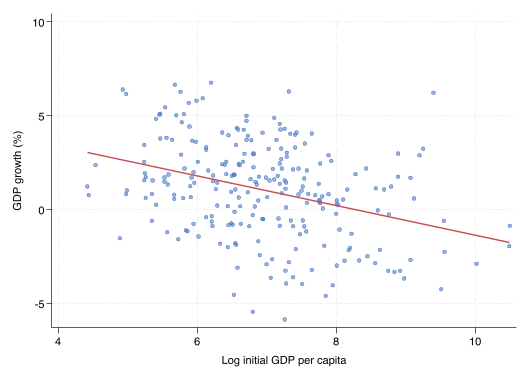

In [4]:
#| label: fig-stata-convergence
#| fig-cap: "Conditional convergence: GDP growth vs. initial income level (Stata)."

twoway ///
    (scatter gdp_growth ln_initial_gdp, ///
        msize(small) mcolor("68 114 196%50") msymbol(circle)) ///
    (lfit gdp_growth ln_initial_gdp, ///
        lcolor("196 78 82") lwidth(medthick)), ///
    ytitle("GDP growth (%)") ///
    xtitle("Log initial GDP per capita") ///
    legend(off) ///
    graphregion(color(white)) plotregion(color(white))

quietly graph export "../images/fig-stata-convergence.png", replace width(1800)

### Correlation Matrix

Stata’s `correlate` command displays the pairwise correlation matrix. This helps identify which variables are most strongly associated with GDP growth and whether any regressors are highly correlated with each other (a sign of multicollinearity).

In [5]:
#| label: fig-stata-correlation
#| fig-cap: "Pairwise correlations between panel variables (Stata)."

correlate gdp_growth ln_initial_gdp investment schooling pop_growth trade_openness

(obs=240)

             | gdp_gr~h ln_ini~p invest~t school~g pop_gr~h trade_~s
-------------+------------------------------------------------------
  gdp_growth |   1.0000
ln_initial~p |  -0.3475   1.0000
  investment |   0.3921  -0.0609   1.0000
   schooling |   0.2116   0.0330   0.0219   1.0000
  pop_growth |  -0.2042   0.0545  -0.1553   0.0078   1.0000
trade_open~s |   0.0915   0.0637   0.0778  -0.0542   0.0135   1.0000


## 3. Panel Data Regressions

We estimate the growth equation using Stata’s `reghdfe` package, which efficiently absorbs high-dimensional fixed effects. Unlike the standard `xtreg` command, `reghdfe` can handle multiple sets of fixed effects simultaneously.

### Estimation

We estimate four models of increasing complexity:

-   **Model 1 (OLS):** Standard linear regression — ignores the panel structure
-   **Model 2 (Country FE):** Absorbs country-specific intercepts via `absorb(country)`
-   **Model 3 (Time FE):** Absorbs period-specific intercepts via `absorb(year)`
-   **Model 4 (Two-way FE):** Absorbs both dimensions via `absorb(country year)`

In all models, standard errors are clustered by country using `vce(cluster country)`.

In [6]:
* Clear any previously stored estimation results
eststo clear

* (1) Pooled OLS — baseline without fixed effects
*     Uses standard 'reg' (not reghdfe) since no FE are absorbed
*     vce(cluster country) produces cluster-robust standard errors
eststo m1: reg gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, vce(cluster country)

* (2) Country FE — absorb time-invariant country characteristics
*     absorb(country) demeans the data within each country
eststo m2: reghdfe gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, absorb(country) vce(cluster country)

* (3) Time FE — absorb period-specific global shocks
eststo m3: reghdfe gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, absorb(year) vce(cluster country)

* (4) Two-way FE — absorb both country and time effects
eststo m4: reghdfe gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, absorb(country year) vce(cluster country)

* --- Add custom scalars for table display ---
* estadd stores user-defined information in the estimation results
* so esttab can include "Country FE: Yes/No" rows
quietly {
    estimates restore m1
    estadd local country_fe "No"
    estadd local year_fe "No"
    estimates restore m2
    estadd local country_fe "Yes"
    estadd local year_fe "No"
    estimates restore m3
    estadd local country_fe "No"
    estadd local year_fe "Yes"
    estimates restore m4
    estadd local country_fe "Yes"
    estadd local year_fe "Yes"
}


Linear regression                               Number of obs     =        240
                                                F(5, 39)          =      29.14
                                                Prob > F          =     0.0000
                                                R-squared         =     0.3323
                                                Root MSE          =      2.136

                               (Std. err. adjusted for 40 clusters in country)
------------------------------------------------------------------------------
             |               Robust
  gdp_growth | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
ln_initial~p |  -.7590153   .1167004    -6.50   0.000    -.9950641   -.5229665
  investment |   .1717267    .029609     5.80   0.000     .1118368    .2316166
   schooling |   .1873427   .0444289     4.22   0.000     .0974766    .2772087
  pop_growth |

### Export Regression Tables

We export the regression results in three formats. The `esttab` command (from the `estout` package) handles LaTeX and CSV natively. For Markdown output, we build the table manually using `file write`.

In [7]:
* --- Export LaTeX table ---
* booktabs: professional horizontal rules (\toprule, \midrule, \bottomrule)
* fragment: omit \begin{table} wrapper (for inclusion in other documents)
* drop(_cons): exclude the constant from the table
esttab m1 m2 m3 m4 using "../tables/tbl-stata-regression.tex", replace ///
    booktabs fragment label se star(* 0.10 ** 0.05 *** 0.01) ///
    scalars("country_fe Country FE" "year_fe Year FE" ///
            "N Observations" "r2_a Adj. R-squared") ///
    sfmt(%s %s %9.0f %9.3f) ///
    mtitles("OLS" "Country FE" "Time FE" "Two-way FE") ///
    drop(_cons)

* --- Export CSV table ---
esttab m1 m2 m3 m4 using "../tables/tbl-stata-regression.csv", replace ///
    csv se star(* 0.10 ** 0.05 *** 0.01) ///
    scalars("country_fe Country FE" "year_fe Year FE" ///
            "N Observations" "r2_a Adj. R-squared") ///
    sfmt(%s %s %9.0f %9.3f) ///
    mtitles("OLS" "Country FE" "Time FE" "Two-way FE") ///
    drop(_cons)

(output written to ../tables/tbl-stata-regression.tex)
(output written to ../tables/tbl-stata-regression.csv)

In [8]:
* --- Build Markdown regression table manually ---
* esttab does not produce clean pipe-delimited Markdown, so we construct
* the table row-by-row using file write

tempname fh
file open `fh' using "../tables/tbl-stata-regression.md", write replace

* Header row with model names
file write `fh' "| | (1) OLS | (2) Country FE | (3) Time FE | (4) Two-way FE |" _n
file write `fh' "|:---|:---:|:---:|:---:|:---:|" _n

* Define the regressors to include (excluding the constant)
local varlist "ln_initial_gdp investment schooling pop_growth trade_openness"
local labels `" "Log initial GDP" "Investment" "Schooling" "Pop. growth" "Trade openness" "'

* Loop over variables and models to build coefficient + SE rows
local v = 1
foreach var of local varlist {
    local vlabel : word `v' of `labels'
    local coef_line "| `vlabel'"
    local se_line "| "

    forvalues m = 1/4 {
        estimates restore m`m'         // Load stored results for model m
        local b = _b[`var']            // Point estimate
        local se = _se[`var']          // Standard error
        if `se' == 0 {
            * Variable not in model (should not happen here)
            local coef_line "`coef_line' | "
            local se_line "`se_line' | "
        }
        else {
            * Compute t-statistic and p-value for significance stars
            local t = `b'/`se'
            local p = 2*ttail(e(df_r), abs(`t'))
            local star ""
            if `p' < 0.01 local star "***"
            else if `p' < 0.05 local star "**"
            else if `p' < 0.10 local star "*"
            local bfmt : display %7.3f `b'
            local sfmt : display %7.3f `se'
            local coef_line "`coef_line' | `=trim("`bfmt'")'`star'"
            local se_line "`se_line' | (`=trim("`sfmt'")')"
        }
    }
    file write `fh' "`coef_line' |" _n
    file write `fh' "`se_line' |" _n
    local v = `v' + 1
}

* Separator row between coefficients and metadata
file write `fh' "| | | | | |" _n

* Fixed effects indicators
file write `fh' "| Country FE | No | Yes | No | Yes |" _n
file write `fh' "| Year FE | No | No | Yes | Yes |" _n

* Fit statistics: number of observations and adjusted R-squared
local obs_line "| Observations"
local r2_line "| Adj. R-squared"
forvalues m = 1/4 {
    estimates restore m`m'
    local n = e(N)
    local r2 : display %5.3f e(r2_a)
    local obs_line "`obs_line' | `n'"
    local r2_line "`r2_line' | `=trim("`r2'")'"
}
file write `fh' "`obs_line' |" _n
file write `fh' "`r2_line' |" _n
file close `fh'

* Display the table inline
type "../tables/tbl-stata-regression.md"

(results m1 are active now)
(results m2 are active now)
(results m3 are active now)
(results m4 are active now)
(results m1 are active now)
(results m2 are active now)
(results m3 are active now)
(results m4 are active now)
(results m1 are active now)
(results m2 are active now)
(results m3 are active now)
(results m4 are active now)
(results m1 are active now)
(results m2 are active now)
(results m3 are active now)
(results m4 are active now)
(results m1 are active now)
(results m2 are active now)
(results m3 are active now)
(results m4 are active now)
(results m1 are active now)
(results m2 are active now)
(results m3 are active now)
(results m4 are active now)
| | (1) OLS | (2) Country FE | (3) Time FE | (4) Two-way FE |
|:---|:---:|:---:|:---:|:---:|
| Log initial GDP | -0.759*** | -0.901*** | -0.742*** | -0.878*** |
|  | (0.117) | (0.088) | (0.109) | (0.084) |
| Investment | 0.172*** | 0.200*** | 0.164*** | 0.190*** |
|  | (0.030) | (0.027) | (0.028) | (0.024) |
| Schooling | 0.18

```` markdown
---
title: "Example of Stata Analysis"
jupyter: nbstata
---

## Overview

This notebook provides a step-by-step introduction to **panel data analysis**
using Stata. It mirrors the Python analysis (notebook-01) using the same
synthetic Barro-style growth dataset, demonstrating that the same econometric
results can be reproduced across different software environments.

The workflow follows three stages:

1. **Data import** — load the panel dataset and declare its structure
2. **Exploratory data analysis** — descriptive statistics, visualization, and correlation analysis
3. **Fixed effects regression** — estimate growth equations using `reghdfe`

**Prerequisites:** Stata must be installed and the `nbstata` kernel
registered. The packages `reghdfe` and `estout` must be installed
(`ssc install reghdfe` and `ssc install estout`).

## 1. Data Import

In Stata, panel data must be explicitly declared using `xtset`. This tells
Stata which variable identifies the entities (countries) and which variable
identifies time periods. The `delta(5)` option indicates that observations
are spaced 5 years apart.

quarto-executable-code-5450563D

```stata
* Clear memory and set the random seed for reproducibility
clear all
set seed 42

* Load the panel dataset generated by the Python notebook
import delimited "../data/panel_growth.csv", clear

* Declare the panel structure: country is the entity, year is the time variable
* delta(5) tells Stata the time gap between observations is 5 years
xtset country year, delta(5)

* Inspect the dataset: variable names, types, and number of observations
describe
```

## 2. Exploratory Data Analysis

### Descriptive Statistics

We compare summary statistics at the beginning (1990) and end (2015) of the
sample period. Each variable appears twice in the table, allowing the reader
to see how the distribution has changed over 25 years.

quarto-executable-code-5450563D

```stata
* Define the variables and their labels for the table
local varlist "gdp_growth ln_initial_gdp investment schooling pop_growth trade_openness"
local labels `" "GDP growth" "Log initial GDP" "Investment" "Schooling" "Pop. growth" "Trade openness" "'

* --- Open output files for all three export formats ---
* Markdown (for the manuscript)
tempname fh
file open `fh' using "../tables/tbl-stata-descriptive.md", write replace
file write `fh' "| Variable | Mean | Median | SD | IQR | Min | Max |" _n
file write `fh' "|:---|:---:|:---:|:---:|:---:|:---:|:---:|" _n

* LaTeX (for standalone use)
tempname fh2
file open `fh2' using "../tables/tbl-stata-descriptive.tex", write replace
file write `fh2' "\begin{tabular}{lcccccc}" _n
file write `fh2' "\toprule" _n
file write `fh2' "Variable & Mean & Median & SD & IQR & Min & Max \\" _n
file write `fh2' "\midrule" _n

* CSV (for data reuse)
tempname fh3
file open `fh3' using "../tables/tbl-stata-descriptive.csv", write replace
file write `fh3' "Variable,Mean,Median,SD,IQR,Min,Max" _n

* --- Compute statistics for each variable at each time point ---
local v = 1
foreach var of local varlist {
    local vlabel : word `v' of `labels'

    foreach yr in 1990 2015 {
        * Subset the data to one period and compute detailed summary statistics
        preserve
        quietly keep if year == `yr'
        quietly summarize `var', detail
        local mn  : display %7.2f r(mean)
        local md  : display %7.2f r(p50)     // Median (50th percentile)
        local sd  : display %7.2f r(sd)
        local iqr : display %7.2f (r(p75) - r(p25))  // Interquartile range
        local lo  : display %7.2f r(min)
        local hi  : display %7.2f r(max)
        restore

        * Write one row to each output file
        file write `fh'  "| `vlabel' (`yr') | `=trim("`mn'")' | `=trim("`md'")' | `=trim("`sd'")' | `=trim("`iqr'")' | `=trim("`lo'")' | `=trim("`hi'")' |" _n
        file write `fh2' "`vlabel' (`yr') & `=trim("`mn'")' & `=trim("`md'")' & `=trim("`sd'")' & `=trim("`iqr'")' & `=trim("`lo'")' & `=trim("`hi'")' \\" _n
        file write `fh3' "`vlabel' (`yr'),`=trim("`mn'")',`=trim("`md'")',`=trim("`sd'")',`=trim("`iqr'")',`=trim("`lo'")',`=trim("`hi'")'" _n
    }
    local v = `v' + 1
}

* Close all output files
file close `fh'
file write `fh2' "\bottomrule" _n
file write `fh2' "\end{tabular}" _n
file close `fh2'
file close `fh3'

* Display the Markdown table inline
type "../tables/tbl-stata-descriptive.md"
```

### GDP Growth Over Time

Box plots show the distribution of GDP growth across 40 countries within
each period. The box spans the interquartile range, the line inside marks
the median, and the dashed line at zero separates positive from negative
growth.

quarto-executable-code-5450563D

```stata
#| label: fig-stata-growth-time
#| fig-cap: "Distribution of GDP per capita growth rates by period (Stata)."

graph box gdp_growth, over(year) ///
    box(1, fcolor("68 114 196") lcolor(black)) ///
    yline(0, lcolor(gray) lpattern(dash) lwidth(thin)) ///
    ytitle("GDP growth (%)") ///
    title("") ///
    graphregion(color(white)) plotregion(color(white))

quietly graph export "../images/fig-stata-growth-time.png", replace width(1800)
```

### Convergence: Growth vs. Initial Income

The convergence hypothesis predicts a negative relationship between initial
income and subsequent growth. The scatter plot shows individual observations
and an OLS fit line summarizing the average relationship.

quarto-executable-code-5450563D

```stata
#| label: fig-stata-convergence
#| fig-cap: "Conditional convergence: GDP growth vs. initial income level (Stata)."

twoway ///
    (scatter gdp_growth ln_initial_gdp, ///
        msize(small) mcolor("68 114 196%50") msymbol(circle)) ///
    (lfit gdp_growth ln_initial_gdp, ///
        lcolor("196 78 82") lwidth(medthick)), ///
    ytitle("GDP growth (%)") ///
    xtitle("Log initial GDP per capita") ///
    legend(off) ///
    graphregion(color(white)) plotregion(color(white))

quietly graph export "../images/fig-stata-convergence.png", replace width(1800)
```

### Correlation Matrix

Stata's `correlate` command displays the pairwise correlation matrix.
This helps identify which variables are most strongly associated with
GDP growth and whether any regressors are highly correlated with each
other (a sign of multicollinearity).

quarto-executable-code-5450563D

```stata
#| label: fig-stata-correlation
#| fig-cap: "Pairwise correlations between panel variables (Stata)."

correlate gdp_growth ln_initial_gdp investment schooling pop_growth trade_openness
```

## 3. Panel Data Regressions

We estimate the growth equation using Stata's `reghdfe` package, which
efficiently absorbs high-dimensional fixed effects. Unlike the standard
`xtreg` command, `reghdfe` can handle multiple sets of fixed effects
simultaneously.

### Estimation

We estimate four models of increasing complexity:

- **Model 1 (OLS):** Standard linear regression — ignores the panel structure
- **Model 2 (Country FE):** Absorbs country-specific intercepts via `absorb(country)`
- **Model 3 (Time FE):** Absorbs period-specific intercepts via `absorb(year)`
- **Model 4 (Two-way FE):** Absorbs both dimensions via `absorb(country year)`

In all models, standard errors are clustered by country using `vce(cluster country)`.

quarto-executable-code-5450563D

```stata
* Clear any previously stored estimation results
eststo clear

* (1) Pooled OLS — baseline without fixed effects
*     Uses standard 'reg' (not reghdfe) since no FE are absorbed
*     vce(cluster country) produces cluster-robust standard errors
eststo m1: reg gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, vce(cluster country)

* (2) Country FE — absorb time-invariant country characteristics
*     absorb(country) demeans the data within each country
eststo m2: reghdfe gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, absorb(country) vce(cluster country)

* (3) Time FE — absorb period-specific global shocks
eststo m3: reghdfe gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, absorb(year) vce(cluster country)

* (4) Two-way FE — absorb both country and time effects
eststo m4: reghdfe gdp_growth ln_initial_gdp investment schooling ///
    pop_growth trade_openness, absorb(country year) vce(cluster country)

* --- Add custom scalars for table display ---
* estadd stores user-defined information in the estimation results
* so esttab can include "Country FE: Yes/No" rows
quietly {
    estimates restore m1
    estadd local country_fe "No"
    estadd local year_fe "No"
    estimates restore m2
    estadd local country_fe "Yes"
    estadd local year_fe "No"
    estimates restore m3
    estadd local country_fe "No"
    estadd local year_fe "Yes"
    estimates restore m4
    estadd local country_fe "Yes"
    estadd local year_fe "Yes"
}
```

### Export Regression Tables

We export the regression results in three formats. The `esttab` command
(from the `estout` package) handles LaTeX and CSV natively. For Markdown
output, we build the table manually using `file write`.

quarto-executable-code-5450563D

```stata
* --- Export LaTeX table ---
* booktabs: professional horizontal rules (\toprule, \midrule, \bottomrule)
* fragment: omit \begin{table} wrapper (for inclusion in other documents)
* drop(_cons): exclude the constant from the table
esttab m1 m2 m3 m4 using "../tables/tbl-stata-regression.tex", replace ///
    booktabs fragment label se star(* 0.10 ** 0.05 *** 0.01) ///
    scalars("country_fe Country FE" "year_fe Year FE" ///
            "N Observations" "r2_a Adj. R-squared") ///
    sfmt(%s %s %9.0f %9.3f) ///
    mtitles("OLS" "Country FE" "Time FE" "Two-way FE") ///
    drop(_cons)

* --- Export CSV table ---
esttab m1 m2 m3 m4 using "../tables/tbl-stata-regression.csv", replace ///
    csv se star(* 0.10 ** 0.05 *** 0.01) ///
    scalars("country_fe Country FE" "year_fe Year FE" ///
            "N Observations" "r2_a Adj. R-squared") ///
    sfmt(%s %s %9.0f %9.3f) ///
    mtitles("OLS" "Country FE" "Time FE" "Two-way FE") ///
    drop(_cons)
```

quarto-executable-code-5450563D

```stata
* --- Build Markdown regression table manually ---
* esttab does not produce clean pipe-delimited Markdown, so we construct
* the table row-by-row using file write

tempname fh
file open `fh' using "../tables/tbl-stata-regression.md", write replace

* Header row with model names
file write `fh' "| | (1) OLS | (2) Country FE | (3) Time FE | (4) Two-way FE |" _n
file write `fh' "|:---|:---:|:---:|:---:|:---:|" _n

* Define the regressors to include (excluding the constant)
local varlist "ln_initial_gdp investment schooling pop_growth trade_openness"
local labels `" "Log initial GDP" "Investment" "Schooling" "Pop. growth" "Trade openness" "'

* Loop over variables and models to build coefficient + SE rows
local v = 1
foreach var of local varlist {
    local vlabel : word `v' of `labels'
    local coef_line "| `vlabel'"
    local se_line "| "

    forvalues m = 1/4 {
        estimates restore m`m'         // Load stored results for model m
        local b = _b[`var']            // Point estimate
        local se = _se[`var']          // Standard error
        if `se' == 0 {
            * Variable not in model (should not happen here)
            local coef_line "`coef_line' | "
            local se_line "`se_line' | "
        }
        else {
            * Compute t-statistic and p-value for significance stars
            local t = `b'/`se'
            local p = 2*ttail(e(df_r), abs(`t'))
            local star ""
            if `p' < 0.01 local star "***"
            else if `p' < 0.05 local star "**"
            else if `p' < 0.10 local star "*"
            local bfmt : display %7.3f `b'
            local sfmt : display %7.3f `se'
            local coef_line "`coef_line' | `=trim("`bfmt'")'`star'"
            local se_line "`se_line' | (`=trim("`sfmt'")')"
        }
    }
    file write `fh' "`coef_line' |" _n
    file write `fh' "`se_line' |" _n
    local v = `v' + 1
}

* Separator row between coefficients and metadata
file write `fh' "| | | | | |" _n

* Fixed effects indicators
file write `fh' "| Country FE | No | Yes | No | Yes |" _n
file write `fh' "| Year FE | No | No | Yes | Yes |" _n

* Fit statistics: number of observations and adjusted R-squared
local obs_line "| Observations"
local r2_line "| Adj. R-squared"
forvalues m = 1/4 {
    estimates restore m`m'
    local n = e(N)
    local r2 : display %5.3f e(r2_a)
    local obs_line "`obs_line' | `n'"
    local r2_line "`r2_line' | `=trim("`r2'")'"
}
file write `fh' "`obs_line' |" _n
file write `fh' "`r2_line' |" _n
file close `fh'

* Display the table inline
type "../tables/tbl-stata-regression.md"
```
````